# CFD Solver (Modular Notebook)
This notebook recreates the original modular structure. Run cells sequentially to generate modules and plots.

In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [40]:
#%%writefile para.py
import numpy as np

device = "CPU"
num_cores = 4
Scheme = "EULER"

# Time
tinit = 0.0
tfinal = 0.01
dt = 1e-4
nsteps = 1000

# Gas properties
gamma = 1.4
R = 287.0

# Initial flow
Mach0 = 2.0
T0 = 300.0
p0 = 101325.0

# Output
t_p = 0.002
output_dir = "output"


Grid Generated: 32 x 32


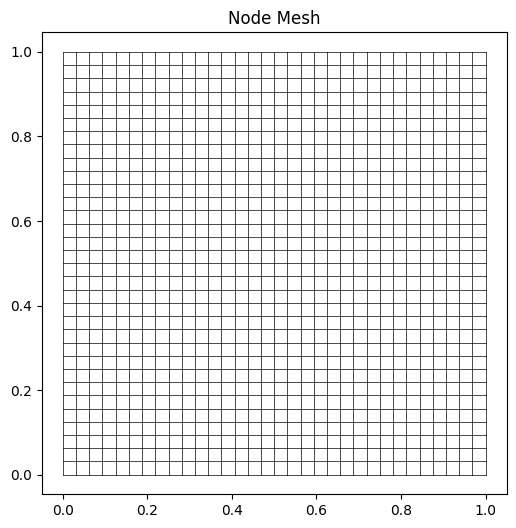

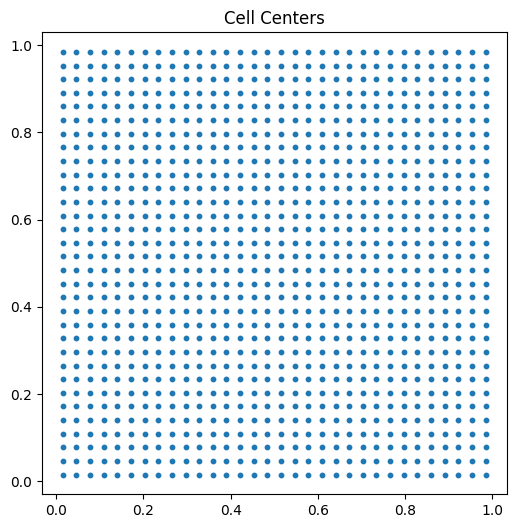

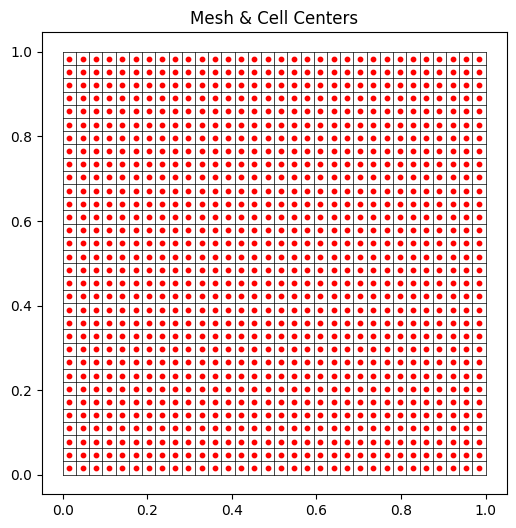

In [42]:
#%%writefile mesh_and_grid.py
import numpy as np
import matplotlib.pyplot as plt

# Backend
ncp = np
copy = np.copy

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------
Lx = 1.0
Ly = 1.0
Nx = 32
Ny = 32

dx = Lx / (Nx)
dy = Ly / (Ny)

# --------------------------------------------------
# NODE-BASED MESH
# --------------------------------------------------
x_nodes = np.linspace(0, Lx, Nx + 1)
y_nodes = np.linspace(0, Ly, Ny + 1)

X_nodes, Y_nodes = np.meshgrid(x_nodes, y_nodes, indexing='ij')

# --------------------------------------------------
# CELL-CENTERED GRID  (IMPORTANT PART)
# --------------------------------------------------
x_centers = (np.arange(Nx) + 0.5) * dx
y_centers = (np.arange(Ny) + 0.5) * dy

X_mesh, Y_mesh = np.meshgrid(x_centers, y_centers, indexing='ij')

# Temporary derivative buffers
temp_dx = np.zeros((Nx, Ny))
temp_dy = np.zeros((Nx, Ny))

print("Grid Generated:", Nx, "x", Ny)


# --------------------------------------------------
# PLOTTING FUNCTIONS
# --------------------------------------------------
def show_mesh():
    plt.figure(figsize=(6,6))
    for i in range(X_nodes.shape[0]):
        plt.plot(X_nodes[i,:], Y_nodes[i,:], 'k-', linewidth=0.5)
    for j in range(X_nodes.shape[1]):
        plt.plot(X_nodes[:,j], Y_nodes[:,j], 'k-', linewidth=0.5)
    plt.title("Node Mesh")
    plt.axis('equal')
    plt.show()


def show_cell_centers():
    plt.figure(figsize=(6,6))
    plt.scatter(X_mesh, Y_mesh, s=10)
    plt.title("Cell Centers")
    plt.axis('equal')
    plt.show()


def show_both():
    plt.figure(figsize=(6,6))
    for i in range(X_nodes.shape[0]):
        plt.plot(X_nodes[i,:], Y_nodes[i,:], 'k-', linewidth=0.5)
    for j in range(X_nodes.shape[1]):
        plt.plot(X_nodes[:,j], Y_nodes[:,j], 'k-', linewidth=0.5)
    plt.scatter(X_mesh, Y_mesh, color='red', s=10)
    plt.title("Mesh & Cell Centers")
    plt.axis('equal')
    plt.show()


# --------------------------------------------------
# Test section (runs when executed directly)
# --------------------------------------------------
if __name__ == "__main__":
    show_mesh()
    show_cell_centers()
    show_both()

Test completed
Mean df/dx = 3.686287386450715e-18
Mean df/dy = -4.119968255444917e-18


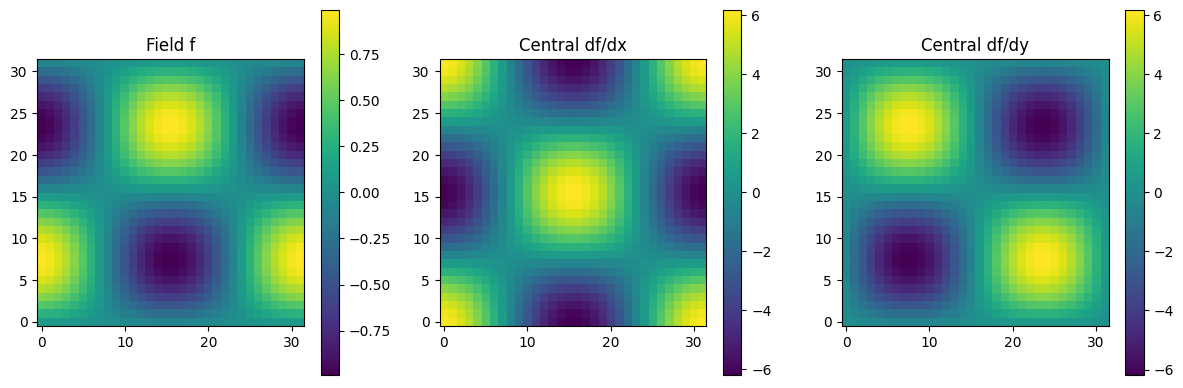

In [44]:
#%%writefile derivative.py
import numpy as np
import matplotlib.pyplot as plt
import mesh_and_grid as grid


# --------------------------------------------------
# Central difference (for verification / testing)
# --------------------------------------------------
def dfx(f):
    """Central difference in x with periodic BC"""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * grid.dx)


def dfy(f):
    """Central difference in y with periodic BC"""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * grid.dy)


# --------------------------------------------------
# Upwind derivatives (used in compressible solver)
# --------------------------------------------------
def dfx_upwind(F, u):
    """First-order upwind derivative in x"""
    df = np.zeros_like(F)

    forward  = (np.roll(F, -1, axis=0) - F) / grid.dx
    backward = (F - np.roll(F, 1, axis=0)) / grid.dx

    df[u > 0] = backward[u > 0]
    df[u <= 0] = forward[u <= 0]

    return df


def dfy_upwind(G, v):
    """First-order upwind derivative in y"""
    dg = np.zeros_like(G)

    forward  = (np.roll(G, -1, axis=1) - G) / grid.dy
    backward = (G - np.roll(G, 1, axis=1)) / grid.dy

    dg[v > 0] = backward[v > 0]
    dg[v <= 0] = forward[v <= 0]

    return dg


# --------------------------------------------------
# Test and visualization
# --------------------------------------------------
def test_derivative():

    X = grid.X_mesh
    Y = grid.Y_mesh

    # Test field
    f = np.sin(2*np.pi*X) * np.cos(2*np.pi*Y)

    dfx_val = dfx(f)
    dfy_val = dfy(f)

    print("Test completed")
    print("Mean df/dx =", np.mean(dfx_val))
    print("Mean df/dy =", np.mean(dfy_val))

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(f, origin='lower')
    plt.title("Field f")
    plt.colorbar()

    plt.subplot(1,3,2)
    plt.imshow(dfx_val, origin='lower')
    plt.title("Central df/dx")
    plt.colorbar()

    plt.subplot(1,3,3)
    plt.imshow(dfy_val, origin='lower')
    plt.title("Central df/dy")
    plt.colorbar()

    plt.tight_layout()
    plt.show()


# Run test automatically if executed directly
if __name__ == "__main__":
    test_derivative()


Grid Generated: 32 x 32
Test completed
Mean df/dx = 3.686287386450715e-18
Mean df/dy = -4.119968255444917e-18


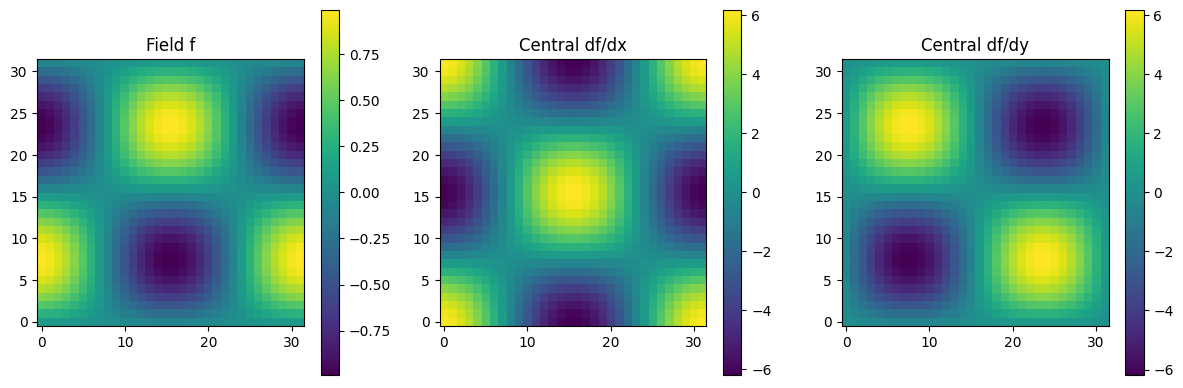

In [45]:
import importlib
import mesh_and_grid
import derivative

importlib.reload(mesh_and_grid)
importlib.reload(derivative)

derivative.test_derivative()


In [61]:
#%%writefile compressible.py
import numpy as np
import mesh_and_grid as grid
from derivative import dfx_upwind, dfy_upwind

gamma = 1.4

# Primitive variables
rho = np.ones((grid.Nx, grid.Ny))
ux  = np.zeros((grid.Nx, grid.Ny))
uy  = np.zeros((grid.Nx, grid.Ny))
p   = np.ones((grid.Nx, grid.Ny)) * 1.0

# Conserved variables
Q = np.zeros((4, grid.Nx, grid.Ny))


# --------------------------------------------------
# Update conserved variables
# --------------------------------------------------
def update_conserved():
    Q[0] = rho
    Q[1] = rho * ux
    Q[2] = rho * uy

    # Total energy per unit mass
    E = p / ((gamma - 1) * rho) + 0.5 * (ux**2 + uy**2)
    Q[3] = rho * E


# --------------------------------------------------
# Update primitive variables
# --------------------------------------------------
def update_primitive():

    # Density floor to avoid division errors
    rho[:] = np.maximum(Q[0], 1e-8)

    ux[:] = Q[1] / rho
    uy[:] = Q[2] / rho

    E = Q[3] / rho
    kinetic = 0.5 * (ux**2 + uy**2)

    # Pressure from EOS
    p_calc = (gamma - 1) * rho * (E - kinetic)

    # Pressure floor for stability
    p[:] = np.maximum(p_calc, 1e-6)


# --------------------------------------------------
# Flux in x-direction
# --------------------------------------------------
def compute_flux_x():

    E = Q[3] / rho

    F0 = rho * ux
    F1 = rho * ux**2 + p
    F2 = rho * ux * uy
    F3 = ux * (rho * E + p)

    return (
        dfx_upwind(F0, ux),
        dfx_upwind(F1, ux),
        dfx_upwind(F2, ux),
        dfx_upwind(F3, ux)
    )


# --------------------------------------------------
# Flux in y-direction
# --------------------------------------------------
def compute_flux_y():

    E = Q[3] / rho

    G0 = rho * uy
    G1 = rho * ux * uy
    G2 = rho * uy**2 + p
    G3 = uy * (rho * E + p)

    return (
        dfy_upwind(G0, uy),
        dfy_upwind(G1, uy),
        dfy_upwind(G2, uy),
        dfy_upwind(G3, uy)
    )


In [62]:
import importlib
import mesh_and_grid
import derivative
import compressible

importlib.reload(mesh_and_grid)
importlib.reload(derivative)
importlib.reload(compressible)

print("Modules loaded successfully")


Grid Generated: 32 x 32
Modules loaded successfully


In [63]:
#%%writefile boundary.py
import numpy as np
import compressible as cs


# --------------------------------------------------
# Periodic BC for velocity
# --------------------------------------------------
def imposeBC_velocity():
    cs.ux[:] = np.roll(cs.ux, 0, axis=0)
    cs.ux[:] = np.roll(cs.ux, 0, axis=1)

    cs.uy[:] = np.roll(cs.uy, 0, axis=0)
    cs.uy[:] = np.roll(cs.uy, 0, axis=1)


# --------------------------------------------------
# Periodic BC for density
# --------------------------------------------------
def imposeBC_rho():
    cs.rho[:] = np.roll(cs.rho, 0, axis=0)
    cs.rho[:] = np.roll(cs.rho, 0, axis=1)


# --------------------------------------------------
# Periodic BC for pressure
# --------------------------------------------------
def imposeBC_pressure():
    cs.p[:] = np.roll(cs.p, 0, axis=0)
    cs.p[:] = np.roll(cs.p, 0, axis=1)


# --------------------------------------------------
# Periodic BC for conserved variables
# --------------------------------------------------
def imposeBC_conserved():
    for k in range(cs.Q.shape[0]):
        cs.Q[k] = np.roll(cs.Q[k], 0, axis=0)
        cs.Q[k] = np.roll(cs.Q[k], 0, axis=1)


# --------------------------------------------------
# Apply all boundary conditions
# --------------------------------------------------
def boundary():
    imposeBC_rho()
    imposeBC_velocity()
    imposeBC_pressure()
    imposeBC_conserved()


In [52]:
#%%writefile init_fields.py
import numpy as np
import para
import compressible as cs
import mesh_and_grid as grid


def init_fields():

    # Read parameters from para.py
    gamma = para.gamma
    R     = para.R
    Mach0 = para.Mach0
    T0    = para.T0
    p0    = para.p0

    # Speed of sound
    a0 = np.sqrt(gamma * R * T0)

    # Flow velocity
    u0 = Mach0 * a0

    # Density from ideal gas law
    rho0 = p0 / (R * T0)

    # Initialize fields
    cs.rho[:] = rho0
    cs.ux[:]  = u0
    cs.uy[:]  = 0.0
    cs.p[:]   = p0

    # Small perturbation (recommended for testing)
    perturb = 1e-3 * np.sin(2*np.pi*grid.X_mesh) * np.sin(2*np.pi*grid.Y_mesh)
    cs.p[:] += perturb

    # Update conserved variables
    cs.update_conserved()

    print("Initialization complete")
    print("Mean density =", cs.rho.mean())
    print("Mean velocity =", cs.ux.mean())
    print("Mean pressure =", cs.p.mean())


In [65]:
#%%writefile saving.py
import numpy as np
import matplotlib.pyplot as plt
import compressible as cs
import mesh_and_grid as grid   # corrected import


def print_output(t):
    print(f"t={t:.5f}  Mean U={cs.ux.mean():.3f}  Mean P={cs.p.mean():.2f}")


def save_plots():

    # Velocity contour
    plt.figure(figsize=(6,5))
    plt.contourf(grid.X_mesh, grid.Y_mesh, cs.ux, 30)
    plt.colorbar(label="Velocity")
    plt.title("Velocity Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig("velocity_contour.png")
    plt.close()

    # Pressure contour
    plt.figure(figsize=(6,5))
    plt.contourf(grid.X_mesh, grid.Y_mesh, cs.p, 30)
    plt.colorbar(label="Pressure")
    plt.title("Pressure Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig("pressure_contour.png")
    plt.close()


In [66]:
#%%writefile init_fields.py
import numpy as np
import mesh_and_grid as grid
import compressible as cs


def init_fields():
    """
    Initialize density, velocity, and pressure fields
    for compressible flow solver.
    """

    # Base uniform state
    rho0 = 1.0
    p0   = 1.0

    # Initialize density
    cs.rho[:] = rho0 * np.ones_like(grid.X_mesh)

    # Small perturbation velocity field (stable initial condition)
    cs.ux[:] = 1e-2 * np.sin(2*np.pi*grid.X_mesh) * np.sin(2*np.pi*grid.Y_mesh)
    cs.uy[:] = -1e-2 * np.cos(2*np.pi*grid.X_mesh) * np.sin(2*np.pi*grid.Y_mesh)

    # Initialize pressure
    cs.p[:] = p0 * np.ones_like(grid.X_mesh)

    # Update conserved variables
    cs.update_conserved()

    print("Fields initialized successfully")


In [67]:
from init_fields import init_fields
init_fields()


Fields initialized successfully


In [68]:
import compressible as cs
print(cs.rho.mean(), cs.p.mean(), cs.ux.mean())


1.0 1.0 -8.880611056369305e-21


In [71]:
#%%writefile fns.py
import numpy as np
import compressible as cs
import mesh_and_grid as grid


def time_advance_euler(nsteps=500):

    gamma = 1.4

    for n in range(nsteps):

        # -----------------------------
        # 1️⃣ Compute CFL time step
        # -----------------------------
        a = np.sqrt(gamma * cs.p / cs.rho)

        umax = np.max(np.abs(cs.ux) + a)
        vmax = np.max(np.abs(cs.uy) + a)

        umax = max(umax, 1e-6)
        vmax = max(vmax, 1e-6)

        dt = 0.1 * min(grid.dx / umax, grid.dy / vmax)

        # -----------------------------
        # 2️⃣ Compute flux derivatives
        # -----------------------------
        dFx = cs.compute_flux_x()
        dFy = cs.compute_flux_y()

        # -----------------------------
        # 3️⃣ Update conserved vars
        # -----------------------------
        for k in range(4):
            cs.Q[k] -= dt * (dFx[k] + dFy[k])

        # -----------------------------
        # 4️⃣ Update primitive vars
        # -----------------------------
        cs.update_primitive()

        # -----------------------------
        # 5️⃣ Stability check
        # -----------------------------
        if np.any(cs.p <= 0):
            print("Negative pressure detected!")
            break

        # -----------------------------
        # 6️⃣ Print progress
        # -----------------------------
        if n % 100 == 0:
            print("Step:", n, " dt =", dt, " Mean Pressure:", cs.p.mean())


Fields initialized successfully
Step: 0  dt = 0.002619183574482881  Mean Pressure: 0.9999816659692118
Step: 100  dt = 0.0006523779700736633  Mean Pressure: 0.7804457868374272
Step: 200  dt = 4.795718265255797e-07  Mean Pressure: 0.752549094858403
Step: 300  dt = 4.79786175797605e-07  Mean Pressure: 0.7521852032773324
Step: 400  dt = 4.800009550520821e-07  Mean Pressure: 0.7518222118056981


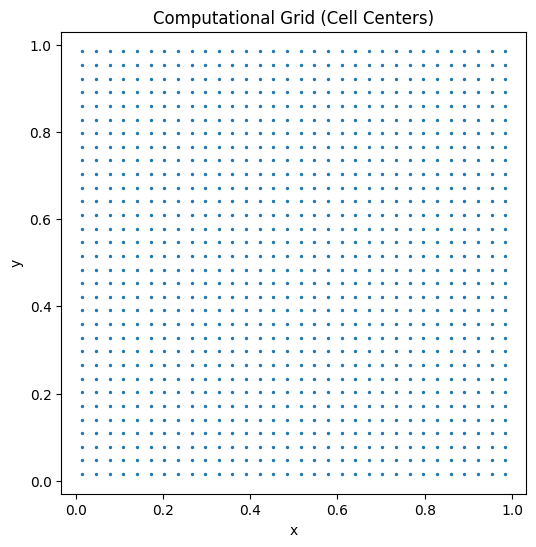

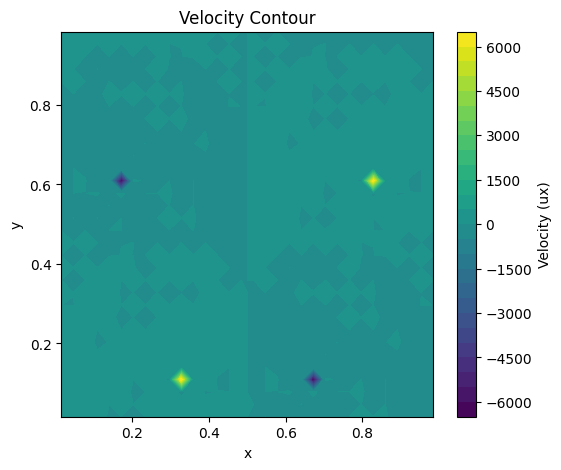

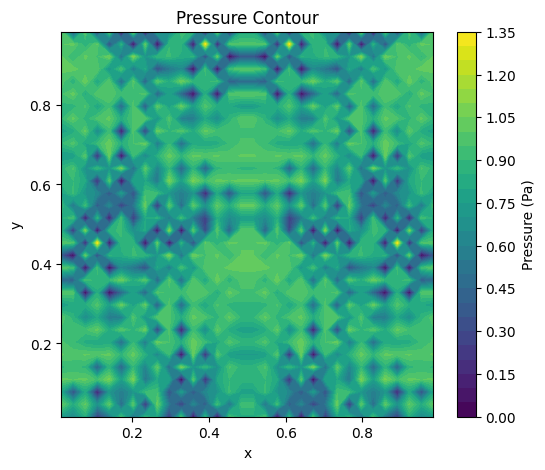


Final Results:
Mean Velocity = 1.2884715516747747e-10
Mean Pressure = 0.7514617379543802
Total time = 0.5094716548919678 seconds


In [73]:
#%%writefile main.py
import time
import matplotlib.pyplot as plt

from init_fields import init_fields
from boundary import boundary
from fns import time_advance_euler
import compressible as cs
import mesh_and_grid as grid


def run_simulation():

    ti = time.time()

    # Initialize and run solver
    init_fields()
    boundary()
    time_advance_euler()

    tf = time.time()

    # -----------------------------
    # Display grid
    # -----------------------------
    plt.figure(figsize=(6,6))
    plt.scatter(grid.X_mesh, grid.Y_mesh, s=2)
    plt.title("Computational Grid (Cell Centers)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.show()

    # -----------------------------
    # Velocity Contour
    # -----------------------------
    plt.figure(figsize=(6,5))
    plt.contourf(grid.X_mesh, grid.Y_mesh, cs.ux, 30)
    plt.colorbar(label="Velocity (ux)")
    plt.title("Velocity Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

    # -----------------------------
    # Pressure Contour
    # -----------------------------
    plt.figure(figsize=(6,5))
    plt.contourf(grid.X_mesh, grid.Y_mesh, cs.p, 30)
    plt.colorbar(label="Pressure (Pa)")
    plt.title("Pressure Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

    # -----------------------------
    # Final Results
    # -----------------------------
    print("\nFinal Results:")
    print("Mean Velocity =", cs.ux.mean())
    print("Mean Pressure =", cs.p.mean())
    print("Total time =", tf-ti, "seconds")


# Run automatically when executed
if __name__ == "__main__":
    run_simulation()


Fields initialized successfully
Step: 0  dt = 0.002619183574482881  Mean Pressure: 0.9999816659692118
Step: 100  dt = 0.0006523779700736633  Mean Pressure: 0.7804457868374272
Step: 200  dt = 4.795718265255797e-07  Mean Pressure: 0.752549094858403
Step: 300  dt = 4.79786175797605e-07  Mean Pressure: 0.7521852032773324
Step: 400  dt = 4.800009550520821e-07  Mean Pressure: 0.7518222118056981


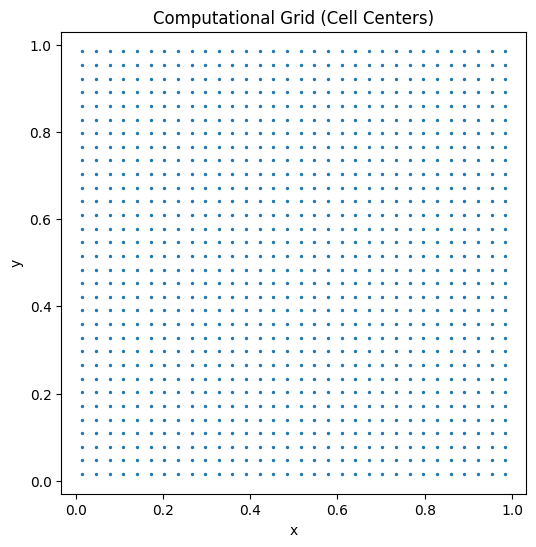

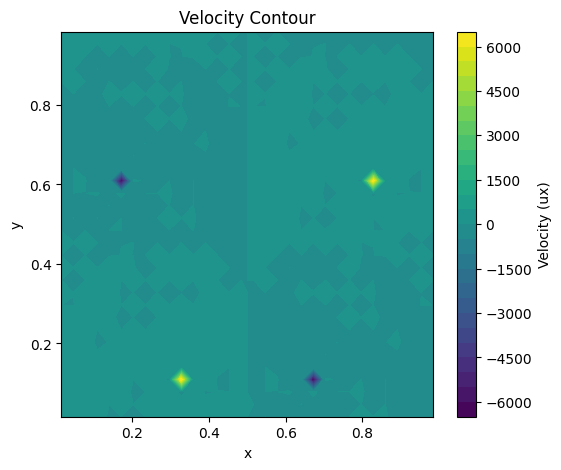

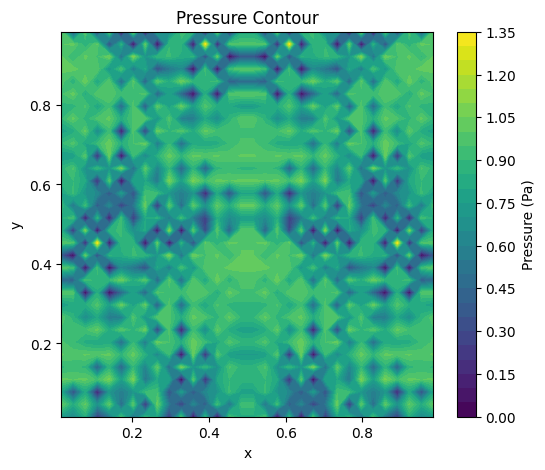


Final Results:
Mean Velocity = 1.2884715516747747e-10
Mean Pressure = 0.7514617379543802
Total time = 0.4150881767272949 seconds


In [74]:
import main
main.run_simulation()
